In [ ]:
import pandas as pd
from datetime import datetime
import numpy as np

In [ ]:
subway1 = pd.read_csv("/content/서울교통공사_역별 시간대별 승하차인원(23.1~23.12) (1).csv", encoding='cp949')
subway2 = pd.read_csv("/content/서울교통공사_역별 시간대별 승하차인원(24.1~24.12).csv", encoding='cp949')
subway3 = pd.read_csv("/content/서울교통공사_역별 일별 시간대별 승하차인원 정보_20221231 (1).csv", encoding='cp949')

In [ ]:
subway2 = subway2.rename(columns={
    '날짜': '수송일자',
    '구분': '승하차구분',
    '06시 이전': '06시이전',
    '06시-07시': '06-07시간대',
    '07시-08시': '07-08시간대',
    '08시-09시': '08-09시간대',
    '09시-10시': '09-10시간대',
    '10시-11시': '10-11시간대',
    '11시-12시': '11-12시간대',
    '12시-13시': '12-13시간대',
    '13시-14시': '13-14시간대',
    '14시-15시': '14-15시간대',
    '15시-16시': '15-16시간대',
    '16시-17시': '16-17시간대',
    '17시-18시': '17-18시간대',
    '18시-19시': '18-19시간대',
    '19시-20시': '19-20시간대',
    '20시-21시': '20-21시간대',
    '21시-22시': '21-22시간대',
    '22시-23시': '22-23시간대',
    '23시-24시': '23-24시간대',
    '24시 이후': '24시이후'
})

In [ ]:
subway3 = subway3.rename(columns={
    '고유역번호(외부역코드)': '역번호'
})

In [ ]:
subway3[subway3["역번호"].astype(str).str.strip() == ""]

,연번,수송일자,호선,역번호,역명,승하차구분,06시이전,06-07시간대,07-08시간대,08-09시간대,...,15-16시간대,16-17시간대,17-18시간대,18-19시간대,19-20시간대,20-21시간대,21-22시간대,22-23시간대,23-24시간대,24시이후


In [ ]:
subway3["역번호"] = subway3["역번호"].astype(int)

In [ ]:
#데이터 합치기
subway_data = pd.concat([subway3, subway1, subway2], axis=0)

In [ ]:
subway_data.tail()

,연번,수송일자,호선,역번호,역명,승하차구분,06시이전,06-07시간대,07-08시간대,08-09시간대,...,15-16시간대,16-17시간대,17-18시간대,18-19시간대,19-20시간대,20-21시간대,21-22시간대,22-23시간대,23-24시간대,24시이후
199405,199406,2024-12-31,8호선,2826,수진,하차,14,85,152,477,...,355,414,465,468,376,261,248,246,175,68.0
199406,199407,2024-12-31,8호선,2827,모란,승차,80,103,332,400,...,389,537,440,381,247,136,170,140,90,50.0
199407,199408,2024-12-31,8호선,2827,모란,하차,19,109,138,428,...,263,340,340,374,281,193,212,207,141,128.0
199408,199409,2024-12-31,8호선,2828,남위례,승차,44,236,686,811,...,656,469,556,513,285,245,216,213,75,46.0
199409,199410,2024-12-31,8호선,2828,남위례,하차,40,138,306,913,...,377,569,664,781,551,342,276,256,148,69.0


In [ ]:
#승차, 하차 데이터 분리
itaewon_get_off = subway_data[(subway_data['역명'] == '이태원') & (subway_data['승하차구분'] == '하차')]

In [ ]:
#시간대 별로 예측을 진행해야 하므로 시간대를 열 -> 행으로 변경

id_vars =['수송일자', '호선', '역번호', '역명', '승하차구분']
value_vars = ['06시이전', '06-07시간대',
    '07-08시간대', '08-09시간대', '09-10시간대', '10-11시간대', '11-12시간대', '12-13시간대',
    '13-14시간대', '14-15시간대', '15-16시간대', '16-17시간대', '17-18시간대', '18-19시간대',
    '19-20시간대', '20-21시간대', '21-22시간대', '22-23시간대', '23-24시간대', '24시이후']

itaewon_get_off_melt = pd.melt(itaewon_get_off,
                            id_vars=id_vars,
                            value_vars=value_vars,
                            var_name='시간대',
                            value_name='이용객수')


In [ ]:
itaewon_get_off_melt.tail()

,수송일자,호선,역번호,역명,승하차구분,시간대,이용객수
21915,2024-12-27,6호선,2631,이태원,하차,24시이후,492.0
21916,2024-12-28,6호선,2631,이태원,하차,24시이후,242.0
21917,2024-12-29,6호선,2631,이태원,하차,24시이후,63.0
21918,2024-12-30,6호선,2631,이태원,하차,24시이후,109.0
21919,2024-12-31,6호선,2631,이태원,하차,24시이후,816.0


In [ ]:
#데이터 통계값 확인
itaewon_get_off_melt.describe()

,역번호,이용객수
count,21920.0,21769.000000
mean,2631.0,628.775461
std,0.0,433.515774
min,2631.0,11.000000
25%,2631.0,354.000000
50%,2631.0,548.000000
75%,2631.0,842.000000
max,2631.0,11873.000000


In [ ]:
itaewon_get_off_melt.isnull().sum()

,0
수송일자,0
호선,0
역번호,0
역명,0
승하차구분,0
시간대,0
이용객수,151


In [ ]:
#null 값 있는 행 제거
itaewon_get_off_melt = itaewon_get_off_melt.dropna().reset_index(drop=True)

In [ ]:
itaewon_get_off_melt.head()

,수송일자,호선,역번호,역명,승하차구분,시간대,이용객수
0,2022-01-01,6,2631,이태원,하차,06시이전,28.0
1,2022-01-02,6,2631,이태원,하차,06시이전,27.0
2,2022-01-03,6,2631,이태원,하차,06시이전,31.0
3,2022-01-04,6,2631,이태원,하차,06시이전,29.0
4,2022-01-05,6,2631,이태원,하차,06시이전,29.0


In [ ]:
def get_ds(row):
    date = pd.to_datetime(row['수송일자'])
    t = row['시간대']
    if '이전' in t:
        time_str = '05:00:00'
    elif '이후' in t:
        date += pd.Timedelta(days=1)  # 다음 날로 이동
        time_str = '00:00:00'
        print('이후')
    else:
        hour = int(t[:2])
        time_str = f'{hour:02d}:00:00'

    return pd.to_datetime(f"{date.date()} {time_str}")

In [ ]:
itaewon_get_off_melt['ds'] = itaewon_get_off_melt.apply(get_ds, axis=1)

이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이

In [ ]:
itaewon_get_off_melt.isnull().sum()

,0
수송일자,0
호선,0
역번호,0
역명,0
승하차구분,0
시간대,0
이용객수,0
ds,0


In [ ]:
itaewon_get_off_melt.head()

,수송일자,호선,역번호,역명,승하차구분,시간대,이용객수,ds
0,2022-01-01,6,2631,이태원,하차,06시이전,28.0,2022-01-01 05:00:00
1,2022-01-02,6,2631,이태원,하차,06시이전,27.0,2022-01-02 05:00:00
2,2022-01-03,6,2631,이태원,하차,06시이전,31.0,2022-01-03 05:00:00
3,2022-01-04,6,2631,이태원,하차,06시이전,29.0,2022-01-04 05:00:00
4,2022-01-05,6,2631,이태원,하차,06시이전,29.0,2022-01-05 05:00:00


In [ ]:
itaewon_get_off_melt.tail()

,수송일자,호선,역번호,역명,승하차구분,시간대,이용객수,ds
21764,2024-12-27,6호선,2631,이태원,하차,24시이후,492.0,2024-12-28
21765,2024-12-28,6호선,2631,이태원,하차,24시이후,242.0,2024-12-29
21766,2024-12-29,6호선,2631,이태원,하차,24시이후,63.0,2024-12-30
21767,2024-12-30,6호선,2631,이태원,하차,24시이후,109.0,2024-12-31
21768,2024-12-31,6호선,2631,이태원,하차,24시이후,816.0,2025-01-01


In [ ]:
itaewon_get_off_melt[itaewon_get_off_melt["ds"].dt.hour == 0]

,수송일자,호선,역번호,역명,승하차구분,시간대,이용객수,ds
20824,2022-06-01,6,2631,이태원,하차,24시이후,24.0,2022-06-02
20825,2022-06-02,6,2631,이태원,하차,24시이후,55.0,2022-06-03
20826,2022-06-03,6,2631,이태원,하차,24시이후,176.0,2022-06-04
20827,2022-06-04,6,2631,이태원,하차,24시이후,248.0,2022-06-05
20828,2022-06-05,6,2631,이태원,하차,24시이후,181.0,2022-06-06
...,...,...,...,...,...,...,...,...
21764,2024-12-27,6호선,2631,이태원,하차,24시이후,492.0,2024-12-28
21765,2024-12-28,6호선,2631,이태원,하차,24시이후,242.0,2024-12-29
21766,2024-12-29,6호선,2631,이태원,하차,24시이후,63.0,2024-12-30
21767,2024-12-30,6호선,2631,이태원,하차,24시이후,109.0,2024-12-31


In [ ]:
itaewon_get_off_melt = itaewon_get_off_melt.rename(columns={
    '이용객수': 'y'
})

In [ ]:
df_prophet = itaewon_get_off_melt[['ds', 'y']].copy()

In [ ]:
df_prophet['hour'] = df_prophet['ds'].dt.hour #시간
df_prophet['dayofweek'] = df_prophet['ds'].dt.day_of_week #요일
df_prophet['month'] = df_prophet['ds'].dt.month #월
df_prophet['is_weekend'] = df_prophet['ds'].dt.dayofweek.isin([5, 6]).astype(int) #주말여부
df_prophet['is_halloween'] = df_prophet['ds'].apply(lambda x: 1 if x.month == 10 and x.day == 31 else 0) #할로윈 여부

In [ ]:
df_prophet

,ds,y,hour,dayofweek,month,is_weekend,is_halloween
0,2022-01-01 05:00:00,28.0,5,5,1,1,0
1,2022-01-02 05:00:00,27.0,5,6,1,1,0
2,2022-01-03 05:00:00,31.0,5,0,1,0,0
3,2022-01-04 05:00:00,29.0,5,1,1,0,0
4,2022-01-05 05:00:00,29.0,5,2,1,0,0
...,...,...,...,...,...,...,...
21764,2024-12-28 00:00:00,492.0,0,5,12,1,0
21765,2024-12-29 00:00:00,242.0,0,6,12,1,0
21766,2024-12-30 00:00:00,63.0,0,0,12,0,0
21767,2024-12-31 00:00:00,109.0,0,1,12,0,0


In [ ]:
# 시계열 데이터의 경우 주기성을 가지기 때문에 원핫 인코딩 x인 버전으로 해보라는 지피티의 조언이 있었음
df_prophet = pd.get_dummies(df_prophet, columns=['dayofweek', 'month', 'hour'], drop_first=True, dtype=int)

In [ ]:
df_prophet.head()

,ds,y,is_weekend,is_halloween,dayofweek_1,dayofweek_2,dayofweek_3,dayofweek_4,dayofweek_5,dayofweek_6,...,hour_14,hour_15,hour_16,hour_17,hour_18,hour_19,hour_20,hour_21,hour_22,hour_23
0,2022-01-01 05:00:00,28.0,1,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
1,2022-01-02 05:00:00,27.0,1,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
2,2022-01-03 05:00:00,31.0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,2022-01-04 05:00:00,29.0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,2022-01-05 05:00:00,29.0,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
df_prophet.columns

Index(['ds', 'y', 'is_weekend', 'is_halloween', 'dayofweek_1', 'dayofweek_2',
       'dayofweek_3', 'dayofweek_4', 'dayofweek_5', 'dayofweek_6', 'month_2',
       'month_3', 'month_4', 'month_5', 'month_6', 'month_7', 'month_8',
       'month_9', 'month_10', 'month_11', 'month_12', 'hour_5', 'hour_6',
       'hour_7', 'hour_8', 'hour_9', 'hour_10', 'hour_11', 'hour_12',
       'hour_13', 'hour_14', 'hour_15', 'hour_16', 'hour_17', 'hour_18',
       'hour_19', 'hour_20', 'hour_21', 'hour_22', 'hour_23'],
      dtype='object')

In [ ]:
df_prophet.dtypes

,0
ds,datetime64[ns]
y,float64
is_weekend,int64
is_halloween,int64
dayofweek_1,int64
dayofweek_2,int64
dayofweek_3,int64
dayofweek_4,int64
dayofweek_5,int64
dayofweek_6,int64


In [ ]:
from prophet import Prophet

# Prophet 모델 생성 및 학습

#dail, weekly 패턴 학습하도록 설정(지하철 특성 반영)
model = Prophet(
    daily_seasonality=True,
    weekly_seasonality=True,
    changepoint_prior_scale=0.1
)


for col in df_prophet.columns:
    if col.startswith('month_') or col.startswith('dayofweek_') or col.startswith('hour_'):
        model.add_regressor(col)
model.add_regressor('is_weekend')
model.add_regressor('is_halloween')
# 한국 공휴일 추가
model.add_country_holidays(country_name='KR')

In [ ]:
#모델 학습
model.fit(df_prophet)

In [ ]:
from prophet.diagnostics import cross_validation, performance_metrics
df_cv = cross_validation(model, initial='365 days', period='7 days', horizon='24 hours')

INFO:prophet:Making 105 forecasts with cutoffs between 2023-01-03 00:00:00 and 2024-12-31 00:00:00


  0%|          | 0/105 [00:00<?, ?it/s]

In [ ]:
df_cv

,ds,yhat,yhat_lower,yhat_upper,y,cutoff
0,2023-01-03 05:00:00,244.649935,-215.948282,691.611631,38.0,2023-01-03
1,2023-01-03 06:00:00,404.054385,-65.166845,847.737868,273.0,2023-01-03
2,2023-01-03 07:00:00,524.633599,107.283339,994.946404,420.0,2023-01-03
3,2023-01-03 08:00:00,993.945393,541.338496,1402.374922,999.0,2023-01-03
4,2023-01-03 09:00:00,851.399232,431.163391,1335.781253,848.0,2023-01-03
...,...,...,...,...,...,...
2095,2024-12-31 20:00:00,570.704698,241.869282,928.044562,1730.0,2024-12-31
2096,2024-12-31 21:00:00,464.260624,135.707252,794.888257,1887.0,2024-12-31
2097,2024-12-31 22:00:00,383.167519,27.705559,711.627353,2267.0,2024-12-31
2098,2024-12-31 23:00:00,260.306834,-69.732144,593.737500,1900.0,2024-12-31


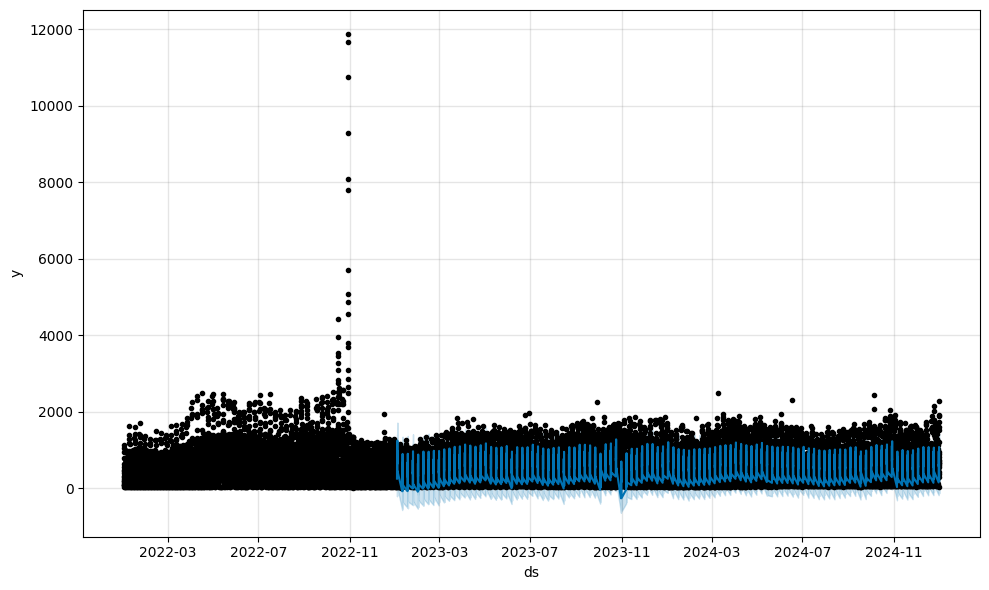

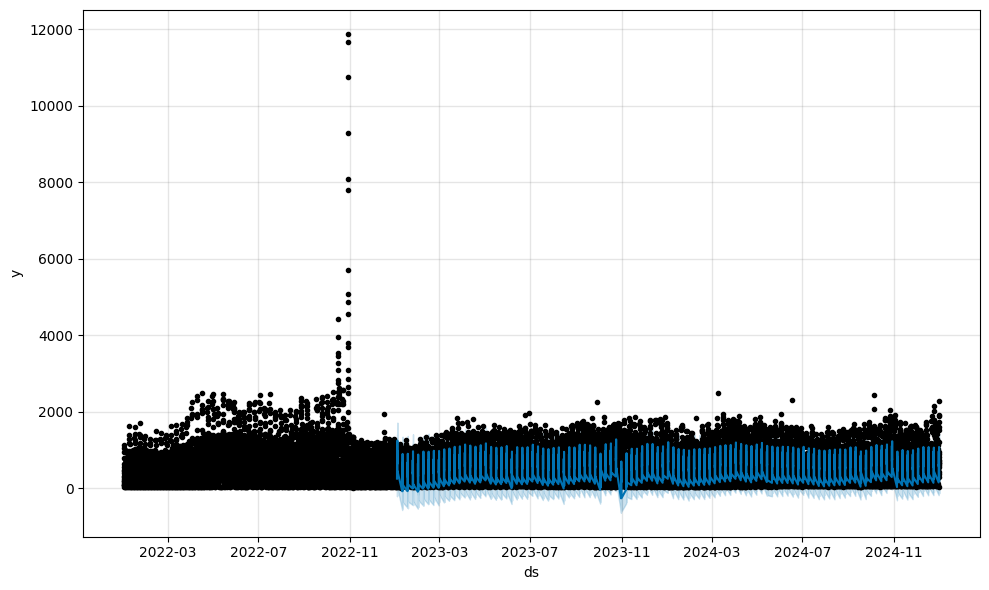

In [ ]:
model.plot(df_cv)

In [ ]:
# 성능 지표 확인
df_p = performance_metrics(df_cv)

df_p

,horizon,mse,rmse,mae,mape,mdape,smape,coverage
0,0 days 06:00:00,9289.163378,96.380306,76.967451,1.068878,0.442416,0.621057,0.995238
1,0 days 07:00:00,12374.483725,111.240657,90.649249,0.256980,0.199352,0.271459,0.990476
2,0 days 08:00:00,96620.435552,310.838279,252.936365,0.379478,0.265907,0.342290,0.690476
3,0 days 09:00:00,149887.048510,387.152487,364.891547,0.429715,0.311012,0.394378,0.538095
4,0 days 10:00:00,71215.451484,266.862233,226.042463,0.290005,0.254442,0.299082,0.838095
5,0 days 11:00:00,13645.059173,116.812068,92.009593,0.167801,0.145040,0.174989,0.995238
6,0 days 12:00:00,11877.652853,108.984645,85.662120,0.181184,0.157472,0.170790,0.995238
7,0 days 13:00:00,14432.683349,120.136103,98.052538,0.198305,0.181481,0.184128,0.995238
8,0 days 14:00:00,12488.008620,111.749759,89.878932,0.177264,0.155811,0.169567,0.995238
9,0 days 15:00:00,12247.277167,110.667417,89.050088,0.171560,0.149529,0.167531,0.995238


In [ ]:
df_p.tail()

,horizon,mse,rmse,mae,mape,mdape,smape,coverage
14,0 days 20:00:00,42799.944089,206.881474,119.965833,0.173072,0.118782,0.174240,0.961905
15,0 days 21:00:00,49725.759463,222.992734,113.583583,0.201288,0.128449,0.219175,0.942857
16,0 days 22:00:00,67501.177480,259.809887,126.153766,0.250754,0.176759,0.300065,0.933333
17,0 days 23:00:00,74937.780733,273.747659,131.804856,0.337455,0.253924,0.429952,0.933333
18,1 days 00:00:00,64607.817423,254.180679,175.019362,1.502474,0.840296,0.763682,0.919048


/usr/local/lib/python3.12/dist-packages/prophet/plot.py:547: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  x_plt = df_none['horizon'].astype('timedelta64[ns]').view(np.int64) / float(dt_conversions[i])
/usr/local/lib/python3.12/dist-packages/prophet/plot.py:548: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  x_plt_h = df_h['horizon'].astype('timedelta64[ns]').view(np.int64) / float(dt_conversions[i])


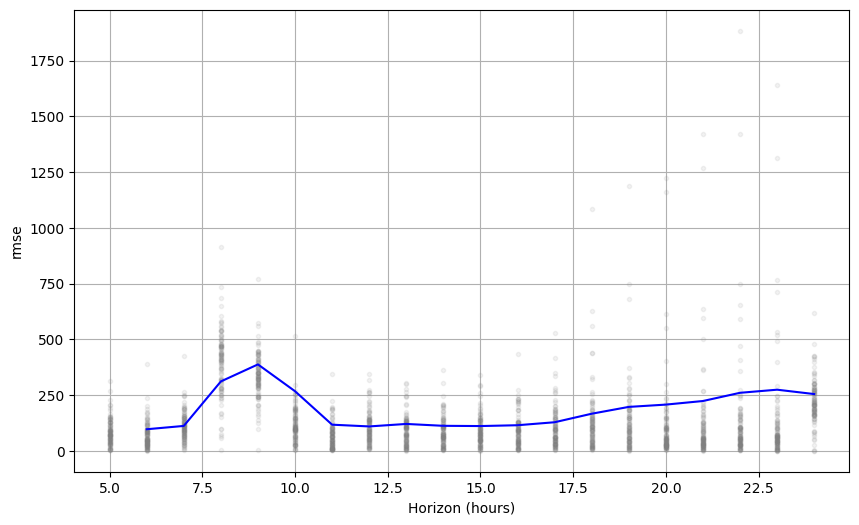

In [ ]:
from prophet.plot import plot_cross_validation_metric
fig = plot_cross_validation_metric(df_cv, metric='rmse')

/usr/local/lib/python3.12/dist-packages/prophet/plot.py:547: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  x_plt = df_none['horizon'].astype('timedelta64[ns]').view(np.int64) / float(dt_conversions[i])
/usr/local/lib/python3.12/dist-packages/prophet/plot.py:548: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  x_plt_h = df_h['horizon'].astype('timedelta64[ns]').view(np.int64) / float(dt_conversions[i])


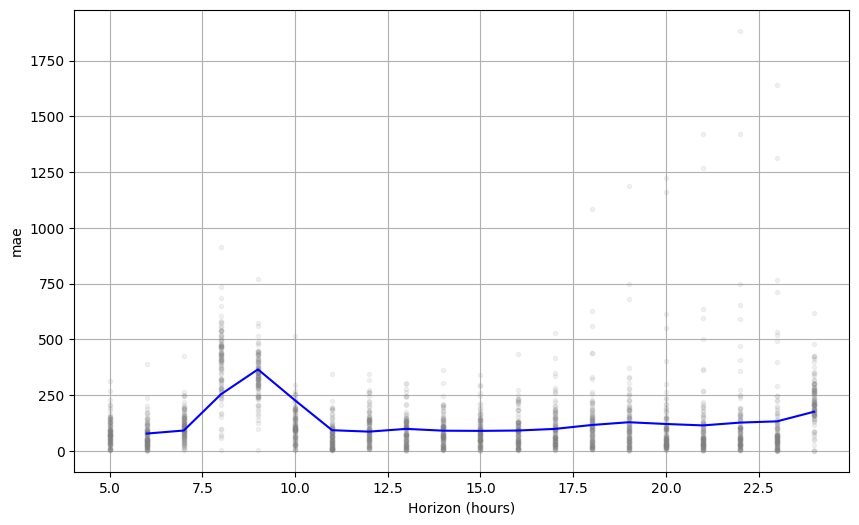

In [ ]:
from prophet.plot import plot_cross_validation_metric
fig = plot_cross_validation_metric(df_cv, metric='mae')

/usr/local/lib/python3.12/dist-packages/prophet/plot.py:547: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  x_plt = df_none['horizon'].astype('timedelta64[ns]').view(np.int64) / float(dt_conversions[i])
/usr/local/lib/python3.12/dist-packages/prophet/plot.py:548: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  x_plt_h = df_h['horizon'].astype('timedelta64[ns]').view(np.int64) / float(dt_conversions[i])


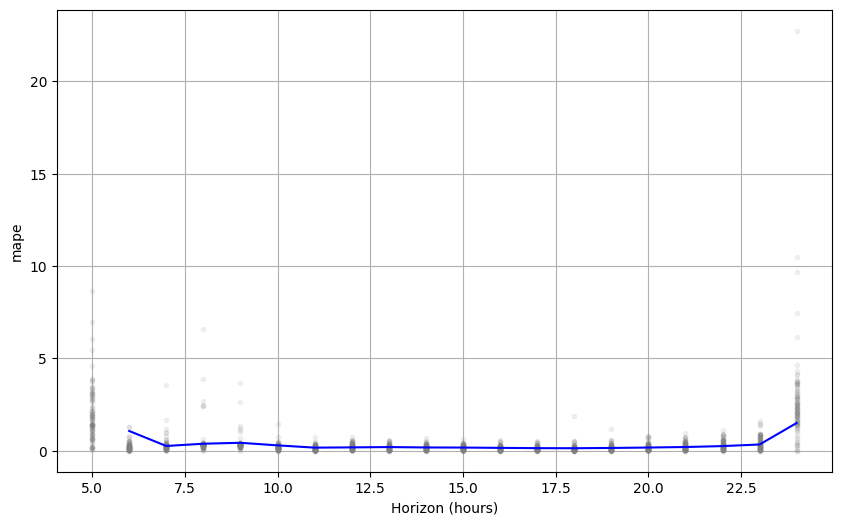

In [ ]:
fig = plot_cross_validation_metric(df_cv, metric='mape')

In [ ]:
df_p.describe()

,horizon,mse,rmse,mae,mape,mdape,smape,coverage
count,19,19.000000,19.000000,19.000000,19.000000,19.000000,19.000000,19.000000
mean,0 days 15:00:00,42065.484984,187.532719,134.963269,0.335051,0.224188,0.275418,0.928321
std,0 days 05:37:38.331619360,37766.884569,85.323671,73.159980,0.352647,0.171395,0.173757,0.120253
min,0 days 06:00:00,9289.163378,96.380306,76.967451,0.135561,0.104449,0.125938,0.538095
25%,0 days 10:30:00,12785.390587,113.064854,90.615063,0.169681,0.135841,0.168549,0.933333
50%,0 days 15:00:00,27549.756168,165.981192,113.583583,0.198305,0.157472,0.184128,0.971429
75%,0 days 19:30:00,66054.497452,256.995283,129.807647,0.313730,0.254183,0.321178,0.995238
max,1 days 00:00:00,149887.048510,387.152487,364.891547,1.502474,0.840296,0.763682,0.995238


In [ ]:
df_p.to_csv("하차_통계.csv", index=False)

In [ ]:
from sklearn.metrics import r2_score

r2 = r2_score(df_cv["y"], df_cv["yhat"])

print(f"Cross Validation R²: {r2:.4f}")

Cross Validation R²: 0.6110


In [ ]:
import joblib
joblib.dump(model, 'get_off_model.pkl')

['get_off_model.pkl']

#2025년 전체 예측

In [ ]:
subway_2025 = pd.read_csv("/content/서울교통공사_역별 일별 시간대별 승하차인원_20251231.csv", encoding='cp949')

In [ ]:
subway_2025.head()

,연번,수송일자,호선,역번호,역명,승하차구분,06시이전,06-07시간대,07-08시간대,08-09시간대,...,15-16시간대,16-17시간대,17-18시간대,18-19시간대,19-20시간대,20-21시간대,21-22시간대,22-23시간대,23-24시간대,24시이후
0,1.0,2025-01-01,1호선,150.0,서울역,승차,411.0,317.0,419.0,733.0,...,3699.0,3694.0,3727.0,3252.0,2925.0,2210.0,2465.0,1555.0,838.0,29.0
1,2.0,2025-01-01,1호선,150.0,서울역,하차,261.0,715.0,941.0,1042.0,...,3061.0,3219.0,3128.0,2591.0,2271.0,2031.0,1553.0,945.0,455.0,130.0
2,3.0,2025-01-01,1호선,151.0,시청,승차,62.0,70.0,122.0,216.0,...,1192.0,1280.0,1276.0,1195.0,926.0,856.0,757.0,444.0,201.0,1.0
3,4.0,2025-01-01,1호선,151.0,시청,하차,70.0,271.0,296.0,479.0,...,1176.0,881.0,775.0,592.0,392.0,289.0,264.0,146.0,76.0,9.0
4,5.0,2025-01-01,1호선,152.0,종각,승차,557.0,211.0,159.0,197.0,...,1284.0,1303.0,1520.0,1490.0,1367.0,1355.0,1168.0,885.0,267.0,9.0


In [ ]:
itaewon_2025 = subway_2025[(subway_2025['역명'] == '이태원') & (subway_2025['승하차구분'] == '하차')]

In [ ]:
itaewon_2025_melt = pd.melt(itaewon_2025,
                            id_vars=id_vars,
                            value_vars=value_vars,
                            var_name='시간대',
                            value_name='이용객수')

In [ ]:
itaewon_2025_melt.head()

,수송일자,호선,역번호,역명,승하차구분,시간대,이용객수
0,2025-01-01,6호선,2631.0,이태원,하차,06시이전,106.0
1,2025-01-02,6호선,2631.0,이태원,하차,06시이전,52.0
2,2025-01-03,6호선,2631.0,이태원,하차,06시이전,61.0
3,2025-01-04,6호선,2631.0,이태원,하차,06시이전,58.0
4,2025-01-05,6호선,2631.0,이태원,하차,06시이전,42.0


In [ ]:
itaewon_2025_melt.isnull().sum()

,0
수송일자,0
호선,0
역번호,0
역명,0
승하차구분,0
시간대,0
이용객수,0


In [ ]:
itaewon_2025_melt['ds'] = itaewon_2025_melt.apply(get_ds, axis=1)

이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이후
이

In [ ]:
itaewon_2025_melt = itaewon_2025_melt.rename(columns={
    '이용객수': 'y'
})

In [ ]:
itaewon_2025_melt.head()

,수송일자,호선,역번호,역명,승하차구분,시간대,y,ds
0,2025-01-01,6호선,2631.0,이태원,하차,06시이전,106.0,2025-01-01 05:00:00
1,2025-01-02,6호선,2631.0,이태원,하차,06시이전,52.0,2025-01-02 05:00:00
2,2025-01-03,6호선,2631.0,이태원,하차,06시이전,61.0,2025-01-03 05:00:00
3,2025-01-04,6호선,2631.0,이태원,하차,06시이전,58.0,2025-01-04 05:00:00
4,2025-01-05,6호선,2631.0,이태원,하차,06시이전,42.0,2025-01-05 05:00:00


In [ ]:
df_prophet_2025 = itaewon_2025_melt[['ds', 'y']].copy()

In [ ]:
df_prophet_2025['hour'] = df_prophet_2025['ds'].dt.hour #시간
df_prophet_2025['dayofweek'] = df_prophet_2025['ds'].dt.day_of_week #요일
df_prophet_2025['month'] = df_prophet_2025['ds'].dt.month #월
df_prophet_2025['is_weekend'] = df_prophet_2025['ds'].dt.dayofweek.isin([5, 6]).astype(int) #주말여부
df_prophet_2025['is_halloween'] = df_prophet_2025['ds'].apply(lambda x: 1 if x.month == 10 and x.day == 31 else 0) #할로윈 여부

In [ ]:
df_prophet_2025

,ds,y,hour,dayofweek,month,is_weekend,is_halloween
0,2025-01-01 05:00:00,106.0,5,2,1,0,0
1,2025-01-02 05:00:00,52.0,5,3,1,0,0
2,2025-01-03 05:00:00,61.0,5,4,1,0,0
3,2025-01-04 05:00:00,58.0,5,5,1,1,0
4,2025-01-05 05:00:00,42.0,5,6,1,1,0
...,...,...,...,...,...,...,...
7295,2025-12-28 00:00:00,267.0,0,6,12,1,0
7296,2025-12-29 00:00:00,125.0,0,0,12,0,0
7297,2025-12-30 00:00:00,144.0,0,1,12,0,0
7298,2025-12-31 00:00:00,151.0,0,2,12,0,0


In [ ]:
df_prophet_2025 = pd.get_dummies(df_prophet_2025, columns=['dayofweek', 'month', 'hour'], drop_first=True, dtype=int)

In [ ]:
df_prophet_2025

,ds,y,is_weekend,is_halloween,dayofweek_1,dayofweek_2,dayofweek_3,dayofweek_4,dayofweek_5,dayofweek_6,...,hour_14,hour_15,hour_16,hour_17,hour_18,hour_19,hour_20,hour_21,hour_22,hour_23
0,2025-01-01 05:00:00,106.0,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,2025-01-02 05:00:00,52.0,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,2025-01-03 05:00:00,61.0,0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
3,2025-01-04 05:00:00,58.0,1,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
4,2025-01-05 05:00:00,42.0,1,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7295,2025-12-28 00:00:00,267.0,1,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
7296,2025-12-29 00:00:00,125.0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
7297,2025-12-30 00:00:00,144.0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
7298,2025-12-31 00:00:00,151.0,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
future = df_prophet_2025.drop(columns='y')

In [ ]:
future.columns

Index(['ds', 'is_weekend', 'is_halloween', 'dayofweek_1', 'dayofweek_2',
       'dayofweek_3', 'dayofweek_4', 'dayofweek_5', 'dayofweek_6', 'month_2',
       'month_3', 'month_4', 'month_5', 'month_6', 'month_7', 'month_8',
       'month_9', 'month_10', 'month_11', 'month_12', 'hour_5', 'hour_6',
       'hour_7', 'hour_8', 'hour_9', 'hour_10', 'hour_11', 'hour_12',
       'hour_13', 'hour_14', 'hour_15', 'hour_16', 'hour_17', 'hour_18',
       'hour_19', 'hour_20', 'hour_21', 'hour_22', 'hour_23'],
      dtype='object')

In [ ]:
future.head()

,ds,is_weekend,is_halloween,dayofweek_1,dayofweek_2,dayofweek_3,dayofweek_4,dayofweek_5,dayofweek_6,month_2,...,hour_14,hour_15,hour_16,hour_17,hour_18,hour_19,hour_20,hour_21,hour_22,hour_23
0,2025-01-01 05:00:00,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,2025-01-02 05:00:00,0,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,2025-01-03 05:00:00,0,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,2025-01-04 05:00:00,1,0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
4,2025-01-05 05:00:00,1,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
forecast = model.predict(future)

In [ ]:
forecast.columns

Index(['ds', 'trend', 'yhat_lower', 'yhat_upper', 'trend_lower', 'trend_upper',
       'Alternative holiday for Buddha's Birthday',
       'Alternative holiday for Buddha's Birthday_lower',
       'Alternative holiday for Buddha's Birthday_upper',
       'Alternative holiday for Children's Day',
       ...
       'weekly', 'weekly_lower', 'weekly_upper', 'yearly', 'yearly_lower',
       'yearly_upper', 'multiplicative_terms', 'multiplicative_terms_lower',
       'multiplicative_terms_upper', 'yhat'],
      dtype='object', length=220)

In [ ]:
forecast.tail()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,Alternative holiday for Buddha's Birthday,Alternative holiday for Buddha's Birthday_lower,Alternative holiday for Buddha's Birthday_upper,Alternative holiday for Children's Day,...,weekly,weekly_lower,weekly_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
7295,2025-12-31 20:00:00,238.832604,-729.450451,2514.482484,-1398.928362,1827.595091,0.0,0.0,0.0,0.0,...,-402.146363,-402.146363,-402.146363,53.073256,53.073256,53.073256,0.0,0.0,0.0,935.181704
7296,2025-12-31 21:00:00,238.866779,-860.226981,2505.932161,-1399.518749,1827.947868,0.0,0.0,0.0,0.0,...,-417.031090,-417.031090,-417.031090,53.083742,53.083742,53.083742,0.0,0.0,0.0,831.070583
7297,2025-12-31 22:00:00,238.900953,-930.836966,2406.067269,-1400.109137,1828.300645,0.0,0.0,0.0,0.0,...,-431.789779,-431.789779,-431.789779,53.094153,53.094153,53.094153,0.0,0.0,0.0,752.687537
7298,2025-12-31 23:00:00,238.935127,-1019.594538,2238.205161,-1400.699525,1828.653422,0.0,0.0,0.0,0.0,...,-446.431657,-446.431657,-446.431657,53.104490,53.104490,53.104490,0.0,0.0,0.0,632.000796
7299,2026-01-01 00:00:00,238.969302,-1155.555232,2158.561864,-1401.289912,1829.006199,0.0,0.0,0.0,0.0,...,-460.965996,-460.965996,-460.965996,53.114755,53.114755,53.114755,0.0,0.0,0.0,522.232774


In [ ]:
result = df_prophet_2025[['ds', 'y']].merge(forecast[['ds', 'yhat']],on='ds')

In [ ]:
result.head()

,ds,y,yhat
0,2025-01-01 05:00:00,106.0,36.836065
1,2025-01-02 05:00:00,52.0,173.465620
2,2025-01-03 05:00:00,61.0,161.534140
3,2025-01-04 05:00:00,58.0,-23.405695
4,2025-01-05 05:00:00,42.0,-53.002339


In [ ]:
r2 = r2_score(result["y"], result["yhat"])
r2

0.30556607622874954

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# MAE
mae = mean_absolute_error(result['y'], result['yhat'])

# RMSE
rmse = np.sqrt(mean_squared_error(result['y'], result['yhat']))

print(f"MAE : {mae:.3f}")
print(f"RMSE: {rmse:.3f}")

MAE : 289.548
RMSE: 343.825


#2025년 중에 하루 예측

In [ ]:
test_one_day = df_prophet_2025[df_prophet_2025['ds'].dt.date == pd.to_datetime('2025-01-15').date()]

In [ ]:
test_one_day

,ds,y,is_weekend,is_halloween,dayofweek_1,dayofweek_2,dayofweek_3,dayofweek_4,dayofweek_5,dayofweek_6,...,hour_14,hour_15,hour_16,hour_17,hour_18,hour_19,hour_20,hour_21,hour_22,hour_23
14,2025-01-15 05:00:00,69.0,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
379,2025-01-15 06:00:00,487.0,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
744,2025-01-15 07:00:00,543.0,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1109,2025-01-15 08:00:00,1186.0,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1474,2025-01-15 09:00:00,1202.0,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1839,2025-01-15 10:00:00,725.0,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2204,2025-01-15 11:00:00,524.0,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2569,2025-01-15 12:00:00,437.0,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2934,2025-01-15 13:00:00,461.0,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3299,2025-01-15 14:00:00,511.0,0,0,0,1,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0


In [ ]:
future_one_day = test_one_day.drop(columns='y')

In [ ]:
future_one_day.columns

Index(['ds', 'is_weekend', 'is_halloween', 'dayofweek_1', 'dayofweek_2',
       'dayofweek_3', 'dayofweek_4', 'dayofweek_5', 'dayofweek_6', 'month_2',
       'month_3', 'month_4', 'month_5', 'month_6', 'month_7', 'month_8',
       'month_9', 'month_10', 'month_11', 'month_12', 'hour_5', 'hour_6',
       'hour_7', 'hour_8', 'hour_9', 'hour_10', 'hour_11', 'hour_12',
       'hour_13', 'hour_14', 'hour_15', 'hour_16', 'hour_17', 'hour_18',
       'hour_19', 'hour_20', 'hour_21', 'hour_22', 'hour_23'],
      dtype='object')

In [ ]:
future_one_day.head()

,ds,is_weekend,is_halloween,dayofweek_1,dayofweek_2,dayofweek_3,dayofweek_4,dayofweek_5,dayofweek_6,month_2,...,hour_14,hour_15,hour_16,hour_17,hour_18,hour_19,hour_20,hour_21,hour_22,hour_23
14,2025-01-15 05:00:00,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
379,2025-01-15 06:00:00,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
744,2025-01-15 07:00:00,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1109,2025-01-15 08:00:00,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1474,2025-01-15 09:00:00,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
forecast_one_day = model.predict(future_one_day)

In [ ]:
forecast_one_day.tail(24)

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,Alternative holiday for Buddha's Birthday,Alternative holiday for Buddha's Birthday_lower,Alternative holiday for Buddha's Birthday_upper,Alternative holiday for Children's Day,...,weekly,weekly_lower,weekly_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2025-01-15 00:00:00,-48.915968,24.218564,748.856891,-48.915968,-48.915968,0.0,0.0,0.0,0.0,...,-77.508077,-77.508077,-77.508077,54.179469,54.179469,54.179469,0.0,0.0,0.0,383.080893
1,2025-01-15 05:00:00,-48.745096,-157.535454,522.472692,-48.745096,-48.745096,0.0,0.0,0.0,0.0,...,-161.802587,-161.802587,-161.802587,54.081400,54.081400,54.081400,0.0,0.0,0.0,184.320447
2,2025-01-15 06:00:00,-48.710921,60.552896,718.996217,-48.710921,-48.710921,0.0,0.0,0.0,0.0,...,-178.630603,-178.630603,-178.630603,54.060992,54.060992,54.060992,0.0,0.0,0.0,385.442264
3,2025-01-15 07:00:00,-48.676747,166.129331,849.222819,-48.676747,-48.676747,0.0,0.0,0.0,0.0,...,-195.400465,-195.400465,-195.400465,54.040319,54.040319,54.040319,0.0,0.0,0.0,487.357148
4,2025-01-15 08:00:00,-48.642572,664.511398,1348.191854,-48.642572,-48.642572,0.0,0.0,0.0,0.0,...,-212.093271,-212.093271,-212.093271,54.019378,54.019378,54.019378,0.0,0.0,0.0,996.361888
5,2025-01-15 09:00:00,-48.608398,541.300125,1206.447713,-48.608398,-48.608398,0.0,0.0,0.0,0.0,...,-228.691574,-228.691574,-228.691574,53.998170,53.998170,53.998170,0.0,0.0,0.0,863.192475
6,2025-01-15 10:00:00,-48.574224,303.769996,990.529672,-48.574224,-48.574224,0.0,0.0,0.0,0.0,...,-245.179680,-245.179680,-245.179680,53.976693,53.976693,53.976693,0.0,0.0,0.0,644.722270
7,2025-01-15 11:00:00,-48.540049,242.058905,910.054457,-48.540049,-48.540049,0.0,0.0,0.0,0.0,...,-261.543909,-261.543909,-261.543909,53.954947,53.954947,53.954947,0.0,0.0,0.0,585.807772
8,2025-01-15 12:00:00,-48.505875,304.826386,978.758433,-48.505875,-48.505875,0.0,0.0,0.0,0.0,...,-277.772789,-277.772789,-277.772789,53.932931,53.932931,53.932931,0.0,0.0,0.0,638.592653
9,2025-01-15 13:00:00,-48.471700,304.964534,994.275971,-48.471700,-48.471700,0.0,0.0,0.0,0.0,...,-293.857212,-293.857212,-293.857212,53.910645,53.910645,53.910645,0.0,0.0,0.0,655.605190


In [ ]:
result_one_day = test_one_day[['ds', 'y']].merge(forecast_one_day[['ds', 'yhat']],on='ds')

In [ ]:
r2 = r2_score(result_one_day["y"], result_one_day["yhat"])
r2

0.6216096519263932

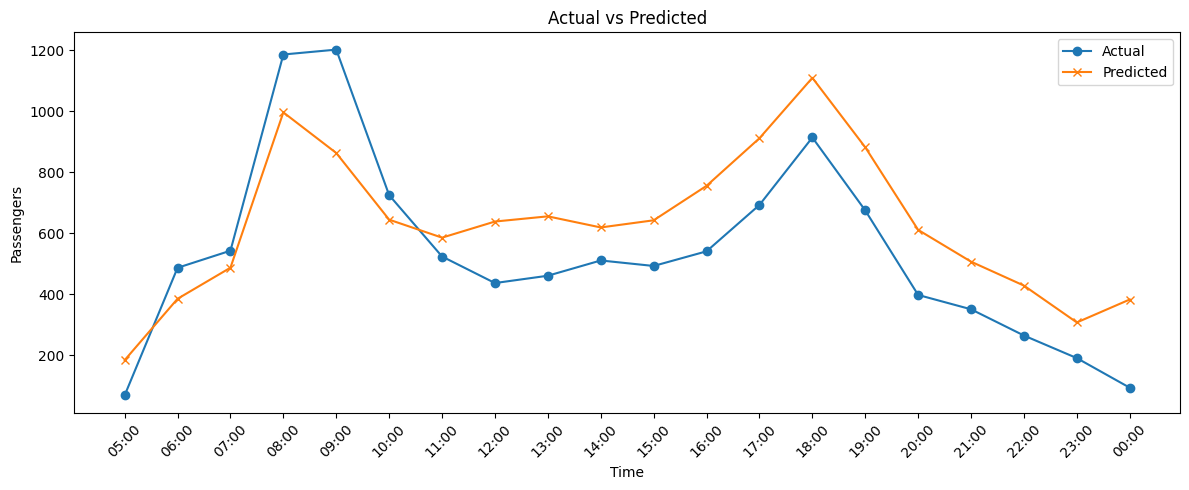

In [ ]:
import matplotlib.pyplot as plt

result_one_day['hour'] = result_one_day['ds'].dt.strftime('%H:%M')


plt.figure(figsize=(12, 5))
plt.plot(result_one_day['hour'], result_one_day['y'], marker='o', label='Actual')
plt.plot(result_one_day['hour'], result_one_day['yhat'], marker='x', label='Predicted')
plt.xlabel('Time')
plt.ylabel('Passengers')
plt.title('Actual vs Predicted')
plt.xticks(rotation=45)
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# MAE
mae = mean_absolute_error(result_one_day['y'], result_one_day['yhat'])

# RMSE
rmse = np.sqrt(mean_squared_error(result_one_day['y'], result_one_day['yhat']))

print(f"MAE : {mae:.3f}")
print(f"RMSE: {rmse:.3f}")

MAE : 168.587
RMSE: 182.906
